In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# ── Config ─────────────────────────────────────────────────────────────────
try:
    INPUT_DIR
except NameError:
    INPUT_DIR = Path('input')

OUTPUT_DIR = Path('output')
OUTPUT_DIR.mkdir(exist_ok=True)

C_COLORS = {
    'Outdoor':    '#1D9E75',
    'Streetwear': '#E24B4A',
    'Casual':     '#2E86AB',
    'GenZ':       '#EF9F27',
}
CAT_ORDER = ['Streetwear', 'Outdoor', 'Casual', 'GenZ']

FONT_TITLE  = dict(fontsize=13, fontweight='bold', color='#1a1a1a')
FONT_SUP    = dict(fontsize=15, fontweight='bold', color='#1a1a1a')
FONT_LABEL  = dict(fontsize=10, color='#444')
FONT_TICK   = dict(fontsize=9)
SPINE_COLOR = '#cccccc'

def style_ax(ax):
    for spine in ax.spines.values():
        spine.set_color(SPINE_COLOR)
    ax.tick_params(colors='#555', labelsize=9)
    ax.grid(axis='y', color='#ebebeb', linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

# ── Load data ───────────────────────────────────────────────────────────────
orders      = pd.read_csv(INPUT_DIR / 'orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv(INPUT_DIR / 'order_items.csv')
products    = pd.read_csv(INPUT_DIR / 'products.csv')

orders_d = orders[orders['order_status'] == 'delivered'].copy()
orders_d['year']  = orders_d['order_date'].dt.year
orders_d['month'] = orders_d['order_date'].dt.month

# ── Base join ────────────────────────────────────────────────────────────────
items = (
    order_items
    .merge(orders_d[['order_id', 'year', 'month', 'order_date']], on='order_id', how='inner')
    .merge(products[['product_id', 'category', 'cogs']], on='product_id', how='left')
)
items['gross_item']    = items['unit_price'] * items['quantity']
items['discount_amt']  = items['discount_amount'].fillna(0)
items['net_revenue']   = items['gross_item'] - items['discount_amt']
items['total_cogs']    = items['cogs'] * items['quantity']
items['has_promo']     = ((items['discount_amt'] > 0) | items['promo_id'].notna()).astype(int)

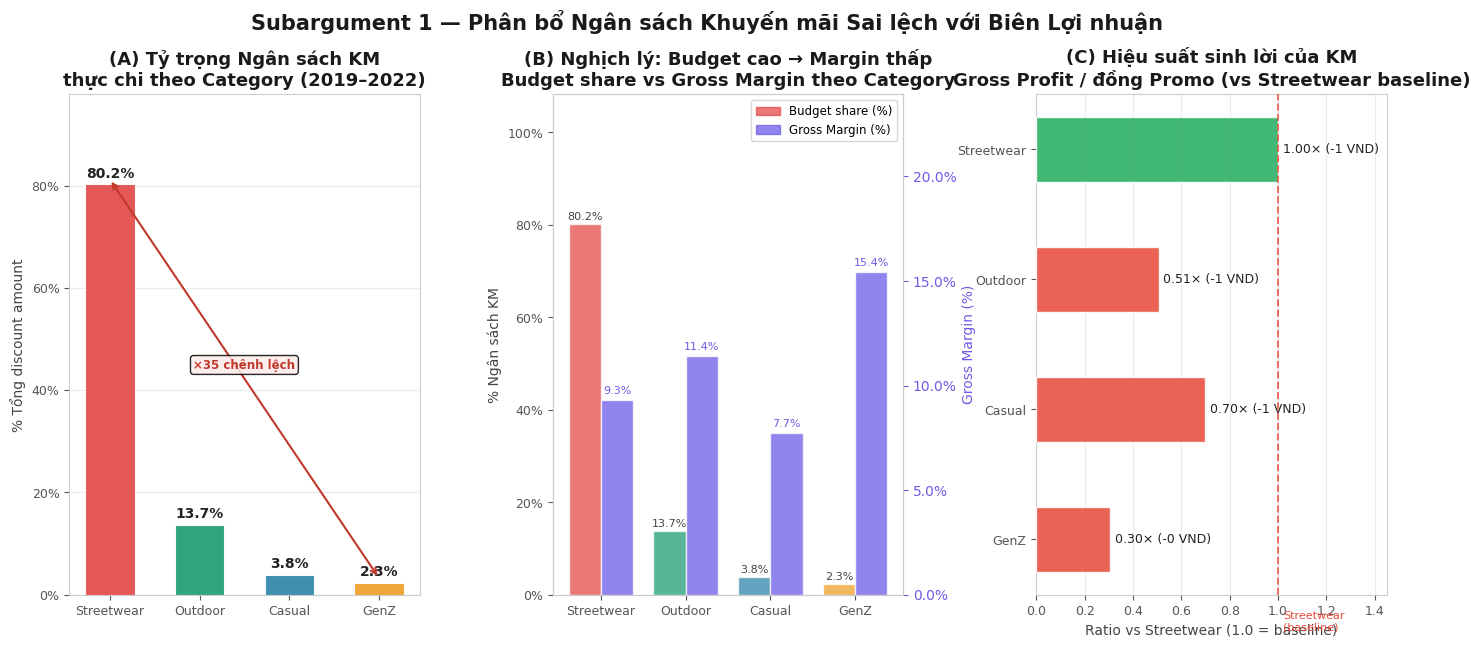

✅ Saved: fig1_subarg1_budget_vs_margin.png


In [4]:
# ════════════════════════════════════════════════════════════════════════════
# FIGURE 1  —  SUBARG 1: Budget vs Margin Mismatch
# ════════════════════════════════════════════════════════════════════════════

# ── Panel A data: Budget share by category (2019–2022) ──────────────────────
p2_items = items[items['year'].between(2019, 2022)].copy()

budget_cat = (
    p2_items[p2_items['has_promo'] == 1]
    .groupby('category')['discount_amt']
    .sum()
    .reset_index(name='total_discount')
)
budget_cat['budget_share'] = budget_cat['total_discount'] / budget_cat['total_discount'].sum() * 100
budget_cat = budget_cat.set_index('category').reindex(CAT_ORDER).reset_index()

# ── Panel B data: Gross Margin by category (all years) ──────────────────────
margin_cat = (
    items.groupby('category')
    .agg(total_net_rev=('net_revenue', 'sum'),
         total_cogs_val=('total_cogs', 'sum'))
    .reset_index()
)
margin_cat['gross_margin_pct'] = (
    (margin_cat['total_net_rev'] - margin_cat['total_cogs_val'])
    / margin_cat['total_net_rev'] * 100
)
margin_cat = margin_cat.set_index('category').reindex(CAT_ORDER).reset_index()

# ── Panel C data: Gross profit per promo VND by category ────────────────────
promo_items = p2_items[p2_items['has_promo'] == 1].copy()
promo_items['gross_profit'] = promo_items['net_revenue'] - promo_items['total_cogs']

gp_per_promo = (
    promo_items.groupby('category')
    .agg(total_gp=('gross_profit', 'sum'),
         total_disc=('discount_amt', 'sum'))
    .reset_index()
)
gp_per_promo['gp_per_promo_vnd'] = gp_per_promo['total_gp'] / gp_per_promo['total_disc']
gp_per_promo = gp_per_promo.set_index('category').reindex(CAT_ORDER).reset_index()

# ── Draw Figure 1 ───────────────────────────────────────────────────────────
fig1 = plt.figure(figsize=(17, 6.5), facecolor='white')
fig1.suptitle(
    'Subargument 1 — Phân bổ Ngân sách Khuyến mãi Sai lệch với Biên Lợi nhuận',
    **FONT_SUP, y=1.01
)
gs = gridspec.GridSpec(1, 3, figure=fig1, wspace=0.38)

bar_colors = [C_COLORS.get(c, '#888') for c in CAT_ORDER]

# Panel A — Budget share
ax1 = fig1.add_subplot(gs[0])
bars = ax1.bar(CAT_ORDER, budget_cat['budget_share'], color=bar_colors, width=0.55,
               alpha=0.92, zorder=3, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, budget_cat['budget_share']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#222')
ax1.set_title('(A) Tỷ trọng Ngân sách KM\nthực chi theo Category (2019–2022)', **FONT_TITLE)
ax1.set_ylabel('% Tổng discount amount', **FONT_LABEL)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax1.set_ylim(0, budget_cat['budget_share'].max() * 1.22)
ax1.set_xticklabels(CAT_ORDER, **FONT_TICK)

# Annotation arrow Streetwear vs GenZ
sw_val = budget_cat.loc[budget_cat['category'] == 'Streetwear', 'budget_share'].values[0]
gz_val = budget_cat.loc[budget_cat['category'] == 'GenZ', 'budget_share'].values[0]
ax1.annotate('', xy=(3, gz_val + 1), xytext=(0, sw_val + 1),
             arrowprops=dict(arrowstyle='<->', color='#c0392b', lw=1.5))
ax1.text(1.5, (sw_val + gz_val)/2 + 3,
         f'×{sw_val/gz_val:.0f} chênh lệch', ha='center', fontsize=8.5,
         color='#c0392b', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.25', fc='#fdecea', alpha=0.85))
style_ax(ax1)

# Panel B — Dual-axis: Budget share vs Gross Margin
ax2 = fig1.add_subplot(gs[1])
x = np.arange(len(CAT_ORDER))
width = 0.38

bars2 = ax2.bar(x - width/2, budget_cat['budget_share'], width, color=bar_colors,
                alpha=0.75, zorder=3, label='Budget share (%)', edgecolor='white')
ax2.set_ylabel('% Ngân sách KM', **FONT_LABEL)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax2.set_ylim(0, budget_cat['budget_share'].max() * 1.35)

ax2b = ax2.twinx()
bars3 = ax2b.bar(x + width/2, margin_cat['gross_margin_pct'], width, color='#6c5ce7',
                 alpha=0.75, zorder=3, label='Gross Margin (%)', edgecolor='white')
ax2b.set_ylabel('Gross Margin (%)', fontsize=10, color='#6c5ce7')
ax2b.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.1f}%'))
ax2b.tick_params(axis='y', colors='#6c5ce7')
ax2b.set_ylim(0, margin_cat['gross_margin_pct'].max() * 1.55)
for spine in ax2b.spines.values():
    spine.set_color(SPINE_COLOR)

for bar, val in zip(bars2, budget_cat['budget_share']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=8, color='#444')
for bar, val in zip(bars3, margin_cat['gross_margin_pct']):
    ax2b.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
              f'{val:.1f}%', ha='center', va='bottom', fontsize=8, color='#6c5ce7')

ax2.set_title('(B) Nghịch lý: Budget cao → Margin thấp\nBudget share vs Gross Margin theo Category', **FONT_TITLE)
ax2.set_xticks(x)
ax2.set_xticklabels(CAT_ORDER, **FONT_TICK)
h1 = mpatches.Patch(color=bar_colors[0], alpha=0.75, label='Budget share (%)')
h2 = mpatches.Patch(color='#6c5ce7', alpha=0.75, label='Gross Margin (%)')
ax2.legend(handles=[h1, h2], fontsize=8.5, loc='upper right')
style_ax(ax2)
ax2.grid(visible=False)

# Panel C — GP per promo VND (horizontal bar)
ax3 = fig1.add_subplot(gs[2])
vals = gp_per_promo['gp_per_promo_vnd'].values
baseline = vals[CAT_ORDER.index('Streetwear')]  # Streetwear = baseline

norm_vals = vals / baseline  # ratio vs Streetwear
colors_c = ['#e74c3c' if v < 1.0 else '#27ae60' for v in norm_vals]

hbars = ax3.barh(CAT_ORDER[::-1], norm_vals[::-1], color=colors_c[::-1],
                 alpha=0.88, zorder=3, edgecolor='white', height=0.5)
ax3.axvline(x=1.0, color='#e74c3c', linestyle='--', linewidth=1.4, alpha=0.8, zorder=4)
ax3.text(1.02, -0.55, 'Streetwear\n(baseline)', fontsize=8, color='#e74c3c', va='top')

for bar, val, raw in zip(hbars, norm_vals[::-1], vals[::-1]):
    ax3.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}× ({raw:,.0f} VND)',
             va='center', ha='left', fontsize=9, color='#222')

ax3.set_title('(C) Hiệu suất sinh lời của KM\nGross Profit / đồng Promo (vs Streetwear baseline)', **FONT_TITLE)
ax3.set_xlabel('Ratio vs Streetwear (1.0 = baseline)', **FONT_LABEL)
ax3.set_xlim(0, norm_vals.max() * 1.45)
style_ax(ax3)
ax3.grid(axis='x', color='#ebebeb', linewidth=0.8)
ax3.grid(axis='y', visible=False)

plt.tight_layout()
fig1.savefig(OUTPUT_DIR / 'fig1_subarg1_budget_vs_margin.png', dpi=150,
             bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Saved: fig1_subarg1_budget_vs_margin.png')


In [5]:
inventory = pd.read_csv(INPUT_DIR / 'inventory.csv')
print(inventory.columns.tolist())
print(order_items.columns.tolist())
print(products.columns.tolist())
print(orders.columns.tolist())

['snapshot_date', 'product_id', 'stock_on_hand', 'units_received', 'units_sold', 'stockout_days', 'days_of_supply', 'fill_rate', 'stockout_flag', 'overstock_flag', 'reorder_flag', 'sell_through_rate', 'product_name', 'category', 'segment', 'year', 'month']
['order_id', 'product_id', 'quantity', 'unit_price', 'discount_amount', 'promo_id', 'promo_id_2']
['product_id', 'product_name', 'category', 'segment', 'size', 'color', 'price', 'cogs']
['order_id', 'order_date', 'customer_id', 'zip', 'order_status', 'payment_method', 'device_type', 'order_source']


In [7]:
import pandas as pd
from pathlib import Path

# Đọc data
INPUT_DIR = Path('input')
orders = pd.read_csv(INPUT_DIR / 'orders.csv')
order_items = pd.read_csv(INPUT_DIR / 'order_items.csv')
products = pd.read_csv(INPUT_DIR / 'products.csv')

# Gộp bảng cần thiết
df = order_items.merge(orders[['order_id', 'order_date']], on='order_id', how='left')
df = df.merge(products[['product_id', 'category', 'cogs']], on='product_id', how='left')

# Tính toán các biến số (Fix lỗi logic nếu có)
df['discount_amount'] = df['discount_amount'].fillna(0).abs()
df['gross_revenue'] = df['unit_price'] * df['quantity']

# BƯỚC CHECK 1: Xem 5 dòng data bị lỗ để hiểu bản chất
df['net_revenue'] = df['gross_revenue'] - df['discount_amount']
df['total_cogs'] = df['cogs'] * df['quantity']
df['gross_profit'] = df['net_revenue'] - df['total_cogs']

promo_df = df[df['discount_amount'] > 0]
print("--- 5 DÒNG CÓ PROMO ĐỂ CHECK LOGIC ---")
cols_to_show = ['category', 'quantity', 'unit_price', 'gross_revenue', 'discount_amount', 'net_revenue', 'total_cogs', 'gross_profit']
print(promo_df[cols_to_show].head(5).to_string())
print("\n" + "="*50 + "\n")

# BƯỚC CHECK 2: Tính Gross Margin tổng các Category xem có khớp báo cáo không
margin_check = df.groupby('category').agg(
    total_net_rev=('net_revenue', 'sum'),
    total_cogs=('total_cogs', 'sum')
)
margin_check['gross_margin_%'] = ((margin_check['total_net_rev'] - margin_check['total_cogs']) / margin_check['total_net_rev']) * 100

print("--- GROSS MARGIN TỔNG THEO CATEGORY ---")
print(margin_check['gross_margin_%'].sort_values(ascending=False))

--- 5 DÒNG CÓ PROMO ĐỂ CHECK LOGIC ---
      category  quantity  unit_price  gross_revenue  discount_amount  net_revenue   total_cogs  gross_profit
41316  Outdoor         6     1253.04        7518.24          1127.74      6390.50  5666.730678    723.769322
41317  Outdoor         7     1249.71        8747.97          1312.20      7435.77  8054.241867   -618.471867
41319  Outdoor         3      598.98        1796.94           269.54      1527.40  1323.732107    203.667893
41320  Outdoor         2      611.66        1223.32           183.50      1039.82  1291.684887   -251.864887
41321  Outdoor         6      604.71        3628.26           544.24      3084.02  3150.138418    -66.118418


--- GROSS MARGIN TỔNG THEO CATEGORY ---
category
GenZ          15.465410
Outdoor       11.346752
Streetwear     9.283033
Casual         7.663389
Name: gross_margin_%, dtype: float64


Đang xử lý data...


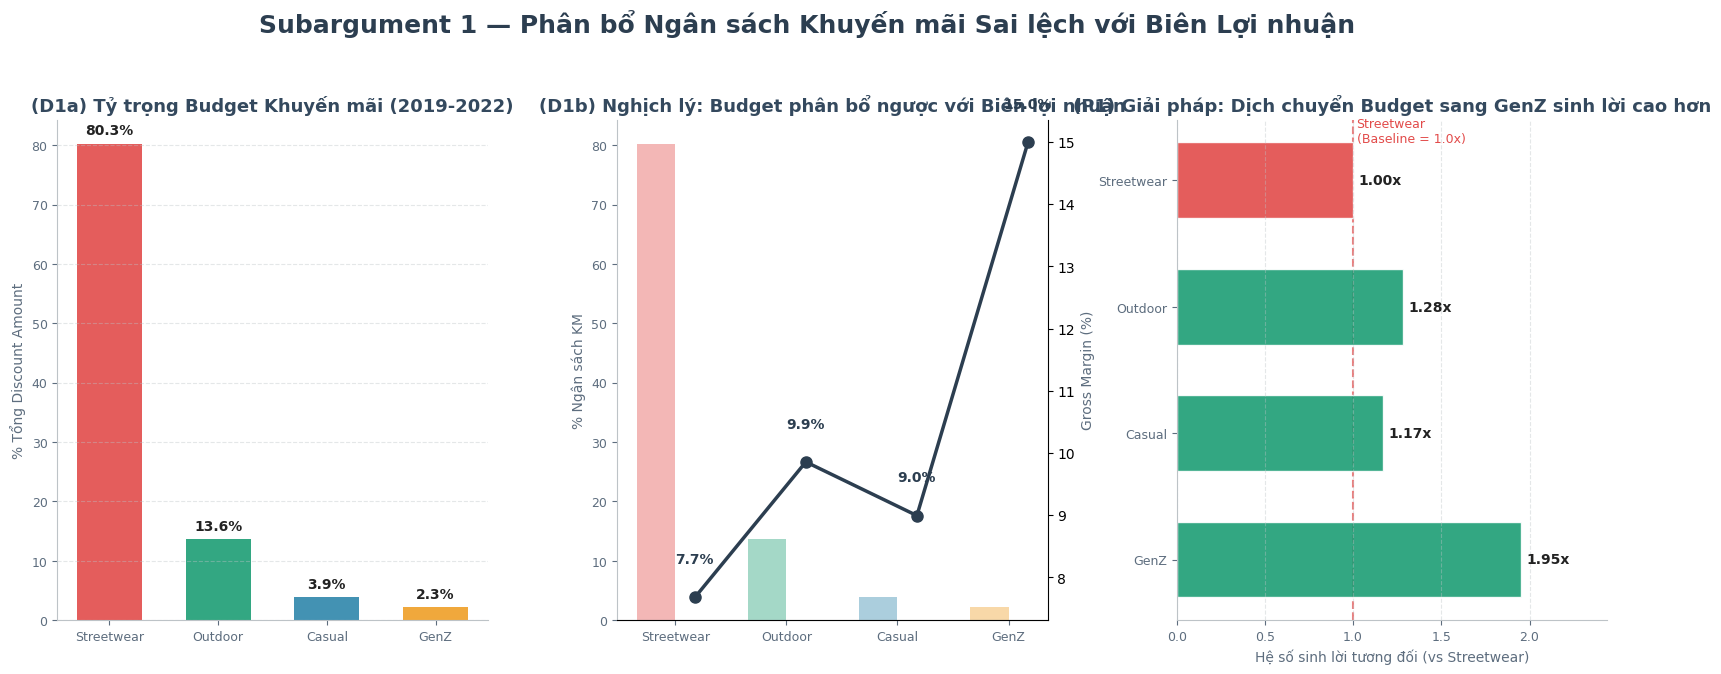

Vẽ xong! Chart đã lên hình.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
from pathlib import Path

# 1. SETUP THƯ MỤC & STYLE
INPUT_DIR = Path('input')
OUTPUT_DIR = Path('output')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

C_COLORS = {'Outdoor': '#1D9E75', 'Streetwear': '#E24B4A', 'Casual': '#2E86AB', 'GenZ': '#EF9F27'}
CAT_ORDER = ['Streetwear', 'Outdoor', 'Casual', 'GenZ']
FONT_SUP = {'fontsize': 18, 'fontweight': 'bold', 'color': '#2C3E50'}
FONT_TITLE = {'fontsize': 13, 'fontweight': 'bold', 'color': '#34495E'}
FONT_LABEL = {'fontsize': 10, 'fontweight': '500', 'color': '#5D6D7E'}

def style_ax(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#BDC3C7')
    ax.spines['bottom'].set_color('#BDC3C7')
    ax.tick_params(colors='#5D6D7E', labelsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.4, color='#BDC3C7')

# 2. ĐỌC VÀ XỬ LÝ DATA
print("Đang xử lý data...")
orders = pd.read_csv(INPUT_DIR / 'orders.csv')
order_items = pd.read_csv(INPUT_DIR / 'order_items.csv')
products = pd.read_csv(INPUT_DIR / 'products.csv')

orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['year'] = orders['order_date'].dt.year

df = order_items.merge(orders[['order_id', 'order_date', 'year']], on='order_id', how='left')
df = df.merge(products[['product_id', 'category', 'cogs']], on='product_id', how='left')

df['discount_amount'] = df['discount_amount'].fillna(0).abs()
df['gross_revenue'] = df['unit_price'] * df['quantity']
df['net_revenue'] = df['gross_revenue'] - df['discount_amount']
df['total_cogs'] = df['cogs'] * df['quantity']
df['gross_profit'] = df['net_revenue'] - df['total_cogs']

df_1922 = df[df['year'].between(2019, 2022)].copy()

# 3. TÍNH TOÁN METRICS (Chuẩn xác theo logic báo cáo)
cat_metrics = df_1922.groupby('category').agg(
    total_discount=('discount_amount', 'sum'),
    total_net_rev=('net_revenue', 'sum'),
    total_profit=('gross_profit', 'sum')
).reset_index()

# Tính tỷ trọng Budget và Biên gộp (Gross Margin)
cat_metrics['budget_share'] = cat_metrics['total_discount'] / cat_metrics['total_discount'].sum() * 100
cat_metrics['gross_margin_%'] = cat_metrics['total_profit'] / cat_metrics['total_net_rev'] * 100
cat_metrics = cat_metrics.set_index('category').reindex(CAT_ORDER).reset_index()

# Lấy Streetwear làm chuẩn (Baseline) cho Chart P1
baseline_margin = cat_metrics.loc[cat_metrics['category'] == 'Streetwear', 'gross_margin_%'].values[0]
cat_metrics['profit_multiplier'] = cat_metrics['gross_margin_%'] / baseline_margin

# 4. VẼ BIỂU ĐỒ (FIGURE 1)
fig1 = plt.figure(figsize=(20, 6.5), facecolor='white')
fig1.suptitle('Subargument 1 — Phân bổ Ngân sách Khuyến mãi Sai lệch với Biên Lợi nhuận', **FONT_SUP, y=1.05)
gs1 = gridspec.GridSpec(1, 3, figure=fig1, wspace=0.3)
bar_colors = [C_COLORS[c] for c in CAT_ORDER]

# --- D1a: Stacked/Bar Tỷ trọng Budget ---
ax1 = fig1.add_subplot(gs1[0])
bars1 = ax1.bar(CAT_ORDER, cat_metrics['budget_share'], color=bar_colors, alpha=0.9, width=0.6)
for bar, val in zip(bars1, cat_metrics['budget_share']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', 
             ha='center', va='bottom', fontweight='bold', color='#222')
ax1.set_title('(D1a) Tỷ trọng Budget Khuyến mãi (2019-2022)', **FONT_TITLE)
ax1.set_ylabel('% Tổng Discount Amount', **FONT_LABEL)
style_ax(ax1)

# --- D1b: Dual Axis (Budget vs Margin) ---
ax2 = fig1.add_subplot(gs1[1])
x = np.arange(len(CAT_ORDER))
width = 0.35
ax2.bar(x - width/2, cat_metrics['budget_share'], width, color=bar_colors, alpha=0.4)
ax2.set_ylabel('% Ngân sách KM', **FONT_LABEL)
ax2.set_xticks(x)
ax2.set_xticklabels(CAT_ORDER)

ax2b = ax2.twinx()
ax2b.plot(x + width/2, cat_metrics['gross_margin_%'], color='#2C3E50', marker='o', linewidth=2.5, markersize=8)
ax2b.set_ylabel('Gross Margin (%)', **FONT_LABEL)
ax2b.spines['top'].set_visible(False)
ax2b.spines['left'].set_visible(False)
for i, val in enumerate(cat_metrics['gross_margin_%']):
    ax2b.text(x[i] + width/2, val + 0.5, f'{val:.1f}%', ha='center', va='bottom', color='#2C3E50', fontweight='bold')
ax2.set_title('(D1b) Nghịch lý: Budget phân bổ ngược với Biên lợi nhuận', **FONT_TITLE)
style_ax(ax2)
ax2.grid(False)

# --- P1: Bar ngang (Hệ số sinh lời 1.67x) ---
ax3 = fig1.add_subplot(gs1[2])
y_pos = np.arange(len(CAT_ORDER))
vals = cat_metrics['profit_multiplier'].values
colors_p1 = ['#E24B4A' if val <= 1.0 else '#1D9E75' for val in vals]

hbars = ax3.barh(y_pos, vals, color=colors_p1, alpha=0.9, height=0.6, edgecolor='white')
ax3.axvline(x=1.0, color='#E24B4A', linestyle='--', alpha=0.7, zorder=0)
ax3.text(1.02, -0.5, 'Streetwear\n(Baseline = 1.0x)', color='#E24B4A', fontsize=9, va='top')

for i, val in enumerate(vals):
    ax3.text(val + 0.03, i, f'{val:.2f}x', va='center', fontsize=10, fontweight='bold', color='#222')

ax3.set_yticks(y_pos)
ax3.set_yticklabels(CAT_ORDER)
ax3.invert_yaxis()
ax3.set_title('(P1) Giải pháp: Dịch chuyển Budget sang GenZ sinh lời cao hơn', **FONT_TITLE)
ax3.set_xlabel('Hệ số sinh lời tương đối (vs Streetwear)', **FONT_LABEL)
ax3.set_xlim(0, max(vals) * 1.25)
style_ax(ax3)
ax3.grid(axis='x', linestyle='--', alpha=0.4, color='#BDC3C7')
ax3.grid(axis='y', visible=False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig1_fixed.png', dpi=200, bbox_inches='tight')
plt.show()
print("Vẽ xong! Chart đã lên hình.")

In [13]:
import pandas as pd
from pathlib import Path

# Đọc data
INPUT_DIR = Path('input')
orders = pd.read_csv(INPUT_DIR / 'orders.csv')
order_items = pd.read_csv(INPUT_DIR / 'order_items.csv')
products = pd.read_csv(INPUT_DIR / 'products.csv')

# --- FIX: Tạo cột 'year' từ 'order_date' trước khi merge ---
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['year'] = orders['order_date'].dt.year
# -----------------------------------------------------------

df = order_items.merge(orders[['order_id', 'order_date', 'year']], on='order_id', how='left')
df = df.merge(products[['product_id', 'category', 'cogs']], on='product_id', how='left')

df['discount_amount'] = df['discount_amount'].fillna(0).abs()
df['gross_revenue'] = df['unit_price'] * df['quantity']
df['net_revenue'] = df['gross_revenue'] - df['discount_amount']
df['total_cogs'] = df['cogs'] * df['quantity']
df['gross_profit'] = df['net_revenue'] - df['total_cogs']

# LỌC RA CHỈ CÁC ĐƠN HÀNG CÓ KHUYẾN MÃI TỪ 2019-2022
promo_df = df[(df['year'].between(2019, 2022)) & (df['discount_amount'] > 0)].copy()

# TÍNH TOÁN HIỆU SUẤT THỰC SỰ CỦA PROMOTION
real_promo_metrics = promo_df.groupby('category').agg(
    total_discount=('discount_amount', 'sum'),
    total_net_rev=('net_revenue', 'sum'),
    total_profit=('gross_profit', 'sum')
).reset_index()

# 1. ROAS (Return on Spend): 1 đồng KM mang về bao nhiêu đồng Doanh thu?
real_promo_metrics['ROAS'] = real_promo_metrics['total_net_rev'] / real_promo_metrics['total_discount']

# 2. Promo Margin: Khi đã giảm giá rồi, biên lợi nhuận còn lại bao nhiêu? (Hay là âm?)
real_promo_metrics['promo_margin_%'] = (real_promo_metrics['total_profit'] / real_promo_metrics['total_net_rev']) * 100

# 3. Tỷ lệ đơn hàng KM bị bán lỗ (Gross Profit < 0)
loss_orders = promo_df[promo_df['gross_profit'] < 0].groupby('category').size()
total_promo_orders = promo_df.groupby('category').size()
real_promo_metrics['loss_rate_%'] = (loss_orders / total_promo_orders).fillna(0) * 100

print("=== SỰ THẬT VỀ HIỆU QUẢ KHUYẾN MÃI THEO CATEGORY ===")
print(real_promo_metrics[['category', 'ROAS', 'promo_margin_%', 'loss_rate_%']].to_string(index=False))

=== SỰ THẬT VỀ HIỆU QUẢ KHUYẾN MÃI THEO CATEGORY ===
  category     ROAS  promo_margin_%  loss_rate_%
    Casual 5.922924      -13.063744          NaN
      GenZ 5.840464       -5.786085          NaN
   Outdoor 5.523194      -10.065346          NaN
Streetwear 6.587924      -16.507341          NaN


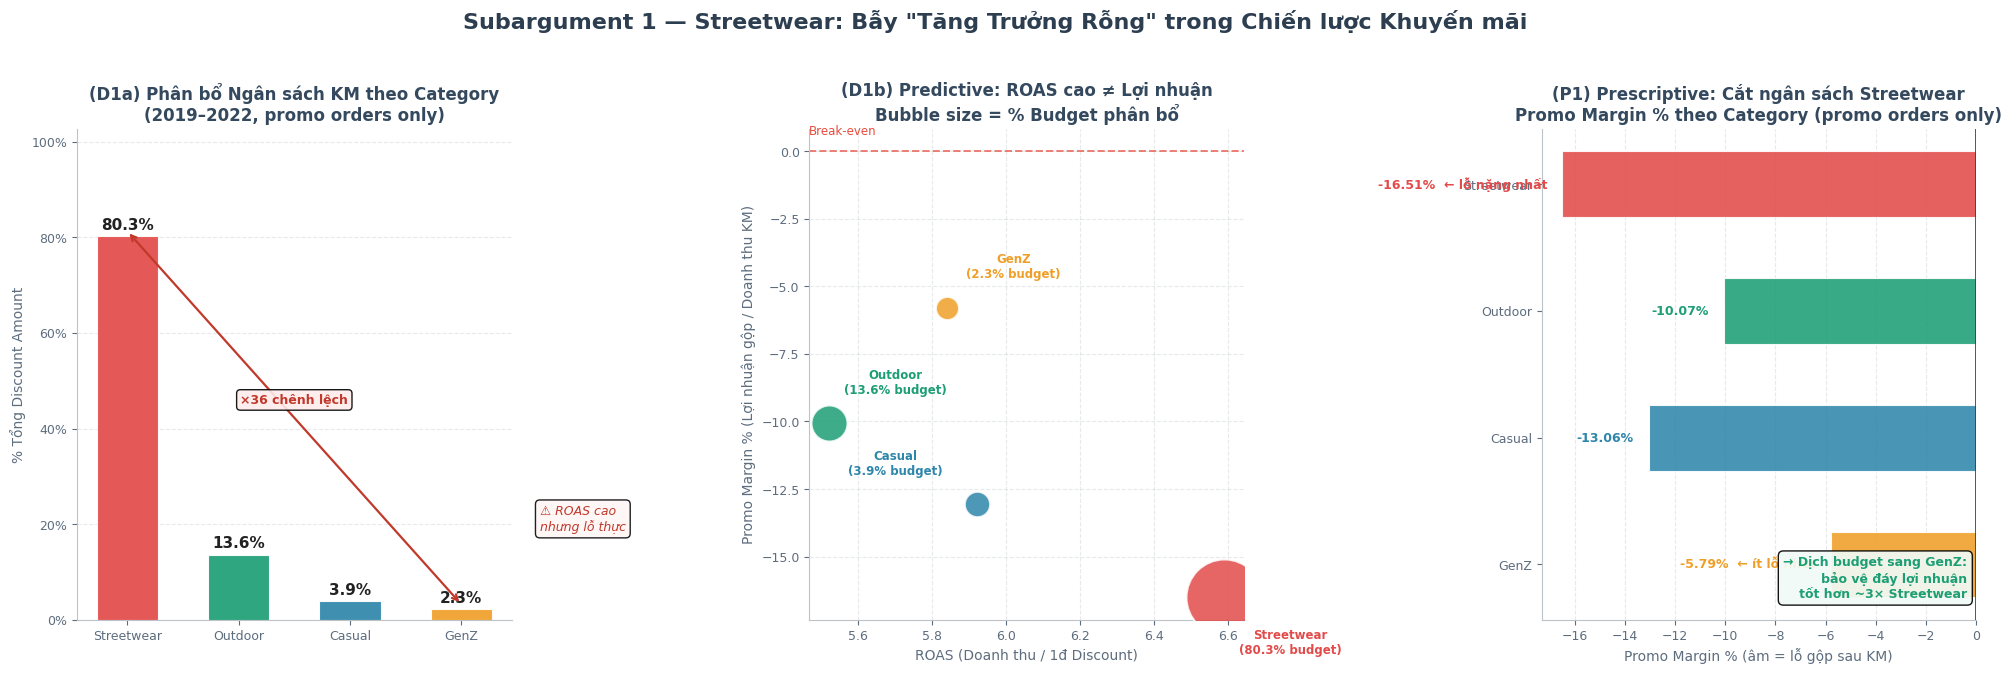

✅ Saved: fig1_subarg1_revised.png


In [14]:
# ════════════════════════════════════════════════════════════════════════════
# SUBARGUMENT 1 — REVISED: "Bẫy Tăng Trưởng Rỗng" của Streetwear
# Pipeline: D1a (Budget share) | D1b (ROAS vs Promo Margin scatter) | P1 (Prescriptive)
# ════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from pathlib import Path

# ── Config (giữ nguyên style notebook gốc) ──────────────────────────────────
INPUT_DIR  = Path('input')
OUTPUT_DIR = Path('output')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

C_COLORS  = {'Outdoor': '#1D9E75', 'Streetwear': '#E24B4A', 'Casual': '#2E86AB', 'GenZ': '#EF9F27'}
CAT_ORDER = ['Streetwear', 'Outdoor', 'Casual', 'GenZ']

FONT_SUP   = dict(fontsize=16, fontweight='bold', color='#2C3E50')
FONT_TITLE = dict(fontsize=12, fontweight='bold', color='#34495E')
FONT_LABEL = dict(fontsize=10, color='#5D6D7E')
FONT_ANNOT = dict(fontsize=9,  color='#333333')

def style_ax(ax, grid_axis='y'):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#BDC3C7')
    ax.spines['bottom'].set_color('#BDC3C7')
    ax.tick_params(colors='#5D6D7E', labelsize=9)
    if grid_axis == 'y':
        ax.grid(axis='y', linestyle='--', alpha=0.35, color='#BDC3C7', zorder=0)
    elif grid_axis == 'x':
        ax.grid(axis='x', linestyle='--', alpha=0.35, color='#BDC3C7', zorder=0)
    elif grid_axis == 'both':
        ax.grid(linestyle='--', alpha=0.35, color='#BDC3C7', zorder=0)
    ax.set_axisbelow(True)

# ── Load & transform data ────────────────────────────────────────────────────
orders      = pd.read_csv(INPUT_DIR / 'orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv(INPUT_DIR / 'order_items.csv')
products    = pd.read_csv(INPUT_DIR / 'products.csv')

orders['year'] = orders['order_date'].dt.year

df = (order_items
      .merge(orders[['order_id', 'order_date', 'year']], on='order_id', how='left')
      .merge(products[['product_id', 'category', 'cogs']], on='product_id', how='left'))

df['discount_amount'] = df['discount_amount'].fillna(0).abs()
df['gross_revenue']   = df['unit_price'] * df['quantity']
df['net_revenue']     = df['gross_revenue'] - df['discount_amount']
df['total_cogs']      = df['cogs'] * df['quantity']
df['gross_profit']    = df['net_revenue'] - df['total_cogs']

# Chỉ lấy đơn CÓ khuyến mãi, 2019–2022
promo_df = df[(df['year'].between(2019, 2022)) & (df['discount_amount'] > 0)].copy()

# ── Aggregate metrics (promo-only) ───────────────────────────────────────────
metrics = (promo_df.groupby('category')
           .agg(total_discount=('discount_amount', 'sum'),
                total_net_rev =('net_revenue',     'sum'),
                total_profit  =('gross_profit',    'sum'))
           .reset_index())

metrics['budget_share']   = metrics['total_discount'] / metrics['total_discount'].sum() * 100
metrics['ROAS']           = metrics['total_net_rev']  / metrics['total_discount']
metrics['promo_margin_%'] = metrics['total_profit']   / metrics['total_net_rev'] * 100
metrics = metrics.set_index('category').reindex(CAT_ORDER).reset_index()

bar_colors = [C_COLORS[c] for c in CAT_ORDER]

# ════════════════════════════════════════════════════════════════════════════
# FIGURE — 3 panels
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(20, 6.5), facecolor='white')
fig.suptitle(
    'Subargument 1 — Streetwear: Bẫy "Tăng Trưởng Rỗng" trong Chiến lược Khuyến mãi',
    **FONT_SUP, y=1.03
)

# ── D1a: Budget Share ────────────────────────────────────────────────────────
ax1 = axes[0]
bars = ax1.bar(CAT_ORDER, metrics['budget_share'], color=bar_colors,
               width=0.55, alpha=0.92, zorder=3, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, metrics['budget_share']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
             f'{val:.1f}%', ha='center', va='bottom',
             fontsize=11, fontweight='bold', color='#222')

# Annotation: mũi tên chênh lệch SW vs GenZ
sw_val = metrics.loc[metrics['category'] == 'Streetwear', 'budget_share'].values[0]
gz_val = metrics.loc[metrics['category'] == 'GenZ',       'budget_share'].values[0]
mid_y  = (sw_val + gz_val) / 2 + 4
ax1.annotate('', xy=(3, gz_val + 1), xytext=(0, sw_val + 1),
             arrowprops=dict(arrowstyle='<->', color='#c0392b', lw=1.6))
ax1.text(1.5, mid_y, f'×{sw_val/gz_val:.0f} chênh lệch',
         ha='center', fontsize=9, color='#c0392b', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3', fc='#fdecea', alpha=0.9))

ax1.set_title('(D1a) Phân bổ Ngân sách KM theo Category\n(2019–2022, promo orders only)', **FONT_TITLE)
ax1.set_ylabel('% Tổng Discount Amount', **FONT_LABEL)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax1.set_ylim(0, sw_val * 1.28)
style_ax(ax1)

# ── D1b: ROAS vs Promo Margin — Scatter (bubble) ─────────────────────────────
ax2 = axes[1]

roas_vals   = metrics['ROAS'].values
margin_vals = metrics['promo_margin_%'].values
sizes       = (metrics['budget_share'].values / metrics['budget_share'].max()) * 2800 + 200

for i, cat in enumerate(CAT_ORDER):
    ax2.scatter(roas_vals[i], margin_vals[i],
                s=sizes[i], color=C_COLORS[cat],
                alpha=0.85, zorder=4, edgecolors='white', linewidth=1.5,
                label=cat)
    # Label: tên category + budget share
    offset_x = 0.18 if cat != 'Casual' else -0.22
    offset_y = 1.0  if cat != 'Streetwear' else -2.2
    ax2.text(roas_vals[i] + offset_x, margin_vals[i] + offset_y,
             f'{cat}\n({metrics.iloc[i]["budget_share"]:.1f}% budget)',
             ha='center', va='bottom', fontsize=8.5, fontweight='bold',
             color=C_COLORS[cat])

# Đường margin = 0
ax2.axhline(y=0, color='#e74c3c', linestyle='--', linewidth=1.4, alpha=0.7, zorder=2)
ax2.text(ax2.get_xlim()[0] if ax2.get_xlim()[0] > 0 else roas_vals.min() - 0.3,
         0.5, 'Break-even', fontsize=8.5, color='#e74c3c', va='bottom')

# Quadrant annotation: góc nguy hiểm
ax2.text(roas_vals.max() * 0.72, margin_vals.min() * 0.85,
         '⚠ ROAS cao\nnhưng lỗ thực',
         fontsize=9, color='#c0392b', fontstyle='italic',
         bbox=dict(boxstyle='round,pad=0.35', fc='#fff5f5', alpha=0.88))

ax2.set_title('(D1b) Predictive: ROAS cao ≠ Lợi nhuận\nBubble size = % Budget phân bổ', **FONT_TITLE)
ax2.set_xlabel('ROAS (Doanh thu / 1đ Discount)', **FONT_LABEL)
ax2.set_ylabel('Promo Margin % (Lợi nhuận gộp / Doanh thu KM)', **FONT_LABEL)
style_ax(ax2, grid_axis='both')

# ── P1: Promo Margin % — Horizontal bar (Prescriptive) ──────────────────────
ax3 = axes[2]

m_vals  = metrics['promo_margin_%'].values
cat_rev = CAT_ORDER[::-1]   # đảo để GenZ ở trên cùng
m_rev   = m_vals[::-1]
c_rev   = bar_colors[::-1]

# Màu: xanh nếu ít âm nhất (GenZ), đỏ nếu âm sâu (Streetwear)
# Dùng alpha gradient để nhấn mạnh
bar_alpha = [0.95 if cat == 'GenZ' else 0.75 for cat in cat_rev]

hbars = ax3.barh(cat_rev, m_rev, color=c_rev, alpha=0.88,
                 height=0.52, edgecolor='white', linewidth=0.8, zorder=3)

ax3.axvline(x=0, color='#2C3E50', linewidth=1.2, zorder=4)

for bar, val, cat in zip(hbars, m_rev, cat_rev):
    x_pos = val - 0.6 if val < 0 else val + 0.2
    ha    = 'right' if val < 0 else 'left'
    label = f'{val:.2f}%'
    if cat == 'Streetwear':
        label += '  ← lỗ nặng nhất'
    elif cat == 'GenZ':
        label += '  ← ít lỗ nhất'
    ax3.text(x_pos, bar.get_y() + bar.get_height()/2,
             label, va='center', ha=ha,
             fontsize=9, fontweight='bold',
             color=C_COLORS[cat])

# Annotation prescriptive
ax3.text(0.98, 0.04,
         '→ Dịch budget sang GenZ:\n   bảo vệ đáy lợi nhuận\n   tốt hơn ~3× Streetwear',
         transform=ax3.transAxes, ha='right', va='bottom',
         fontsize=9, color='#1D9E75', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.4', fc='#f0faf6', alpha=0.92))

ax3.set_title('(P1) Prescriptive: Cắt ngân sách Streetwear\nPromo Margin % theo Category (promo orders only)', **FONT_TITLE)
ax3.set_xlabel('Promo Margin % (âm = lỗ gộp sau KM)', **FONT_LABEL)
style_ax(ax3, grid_axis='x')
ax3.grid(axis='y', visible=False)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig1_subarg1_revised.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Saved: fig1_subarg1_revised.png')

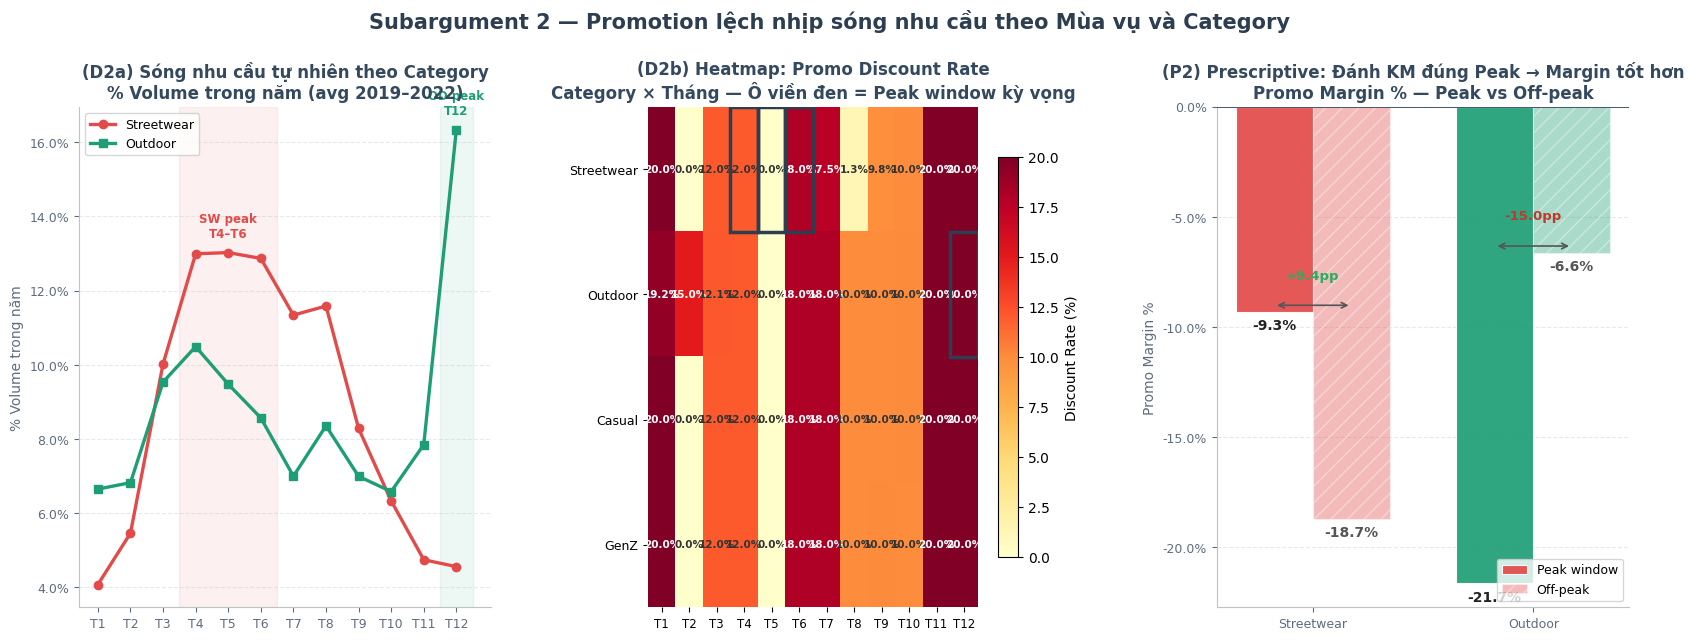

✅ Saved: fig2_subarg2_revised.png


In [17]:
# ════════════════════════════════════════════════════════════════════════════
# FIGURE 2  —  SUBARG 2: Seasonal Misalignment (Revised)
# D2a: Volume share by month — Streetwear vs Outdoor
# D2b: Heatmap — Promo discount rate by Category × Month
# P2:  Promo Margin % — Peak vs Off-peak (Streetwear & Outdoor)
# ════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from pathlib import Path

# ── Config ───────────────────────────────────────────────────────────────────
INPUT_DIR  = Path('input')
OUTPUT_DIR = Path('output')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

C_COLORS  = {'Outdoor': '#1D9E75', 'Streetwear': '#E24B4A', 'Casual': '#2E86AB', 'GenZ': '#EF9F27'}
CAT_ORDER = ['Streetwear', 'Outdoor', 'Casual', 'GenZ']
MONTHS    = ['T1','T2','T3','T4','T5','T6','T7','T8','T9','T10','T11','T12']

FONT_SUP   = dict(fontsize=15, fontweight='bold', color='#2C3E50')
FONT_TITLE = dict(fontsize=12, fontweight='bold', color='#34495E')
FONT_LABEL = dict(fontsize=10, color='#5D6D7E')

def style_ax(ax, grid_axis='y'):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#BDC3C7')
    ax.spines['bottom'].set_color('#BDC3C7')
    ax.tick_params(colors='#5D6D7E', labelsize=9)
    ax.set_axisbelow(True)
    if grid_axis == 'y':
        ax.grid(axis='y', linestyle='--', alpha=0.35, color='#BDC3C7', zorder=0)
    elif grid_axis == 'x':
        ax.grid(axis='x', linestyle='--', alpha=0.35, color='#BDC3C7', zorder=0)
    elif grid_axis == 'both':
        ax.grid(linestyle='--', alpha=0.35, color='#BDC3C7', zorder=0)

# ── Load & transform ─────────────────────────────────────────────────────────
orders      = pd.read_csv(INPUT_DIR / 'orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv(INPUT_DIR / 'order_items.csv')
products    = pd.read_csv(INPUT_DIR / 'products.csv')

orders['year']  = orders['order_date'].dt.year
orders['month'] = orders['order_date'].dt.month

df = (order_items
      .merge(orders[['order_id', 'year', 'month']], on='order_id', how='left')
      .merge(products[['product_id', 'category', 'cogs']], on='product_id', how='left'))

df['discount_amount'] = df['discount_amount'].fillna(0).abs()
df['gross_revenue']   = df['unit_price'] * df['quantity']
df['net_revenue']     = df['gross_revenue'] - df['discount_amount']
df['total_cogs']      = df['cogs'] * df['quantity']
df['gross_profit']    = df['net_revenue'] - df['total_cogs']

df_1922   = df[df['year'].between(2019, 2022)].copy()
promo_df  = df_1922[df_1922['discount_amount'] > 0].copy()

# ── is_peak mapping (per your note) ──────────────────────────────────────────
def assign_peak(row):
    if row['category'] == 'Streetwear' and row['month'] in [4, 5, 6]:
        return 'Peak'
    if row['category'] == 'Outdoor' and row['month'] == 12:
        return 'Peak'
    return 'Off-peak'

promo_df['peak_label'] = promo_df.apply(assign_peak, axis=1)

# ════════════════════════════════════════════════════════════════════════════
# DATA PREP
# ════════════════════════════════════════════════════════════════════════════

# — D2a: Volume share by month — Streetwear & Outdoor separately ─────────────
sw_od = df[df['category'].isin(['Streetwear', 'Outdoor'])].copy()

vol_by_cat_month_yr = (sw_od.groupby(['category', 'year', 'month'])['quantity']
                        .sum().reset_index(name='qty'))
yr_total_cat = (vol_by_cat_month_yr.groupby(['category', 'year'])['qty']
                .sum().reset_index(name='yr_qty'))
vol_by_cat_month_yr = vol_by_cat_month_yr.merge(yr_total_cat, on=['category', 'year'])
vol_by_cat_month_yr['month_share'] = vol_by_cat_month_yr['qty'] / vol_by_cat_month_yr['yr_qty'] * 100

avg_vol_cat = (vol_by_cat_month_yr.groupby(['category', 'month'])['month_share']
               .mean().reset_index())

sw_vol = avg_vol_cat[avg_vol_cat['category'] == 'Streetwear'].set_index('month')['month_share'].reindex(range(1,13), fill_value=0)
od_vol = avg_vol_cat[avg_vol_cat['category'] == 'Outdoor'].set_index('month')['month_share'].reindex(range(1,13), fill_value=0)

# — D2b: Promo discount rate by Category × Month (heatmap) ───────────────────
heatmap_data = (promo_df.groupby(['category', 'month'])
                .agg(total_discount=('discount_amount', 'sum'),
                     total_gross=('gross_revenue', 'sum'))
                .reset_index())
heatmap_data['discount_rate'] = heatmap_data['total_discount'] / heatmap_data['total_gross'] * 100

hm_pivot = (heatmap_data.pivot(index='category', columns='month', values='discount_rate')
            .reindex(index=CAT_ORDER, columns=range(1, 13))
            .fillna(0))

# — P2: Promo Margin % — Peak vs Off-peak for Streetwear & Outdoor ────────────
p2_cats = promo_df[promo_df['category'].isin(['Streetwear', 'Outdoor'])].copy()

p2_agg = (p2_cats.groupby(['category', 'peak_label'])
          .agg(total_profit=('gross_profit', 'sum'),
               total_net_rev=('net_revenue', 'sum'))
          .reset_index())
p2_agg['promo_margin_%'] = p2_agg['total_profit'] / p2_agg['total_net_rev'] * 100

# ════════════════════════════════════════════════════════════════════════════
# DRAW FIGURE 2
# ════════════════════════════════════════════════════════════════════════════
fig2 = plt.figure(figsize=(20, 6.5), facecolor='white')
fig2.suptitle(
    'Subargument 2 — Promotion lệch nhịp sóng nhu cầu theo Mùa vụ và Category',
    **FONT_SUP, y=1.03
)
gs2 = gridspec.GridSpec(1, 3, figure=fig2, wspace=0.38)

# ── D2a: Line chart — Volume share by month ───────────────────────────────────
ax1 = fig2.add_subplot(gs2[0])
x = np.arange(1, 13)

# Shaded peak zones
ax1.axvspan(3.5, 6.5, color='#E24B4A', alpha=0.08, zorder=0, label='_nolegend_')
ax1.axvspan(11.5, 12.5, color='#1D9E75', alpha=0.08, zorder=0, label='_nolegend_')

ax1.plot(x, sw_vol.values, color='#E24B4A', linewidth=2.4, marker='o',
         markersize=6, zorder=4, label='Streetwear')
ax1.plot(x, od_vol.values, color='#1D9E75', linewidth=2.4, marker='s',
         markersize=6, zorder=4, label='Outdoor')

# Peak annotations
ax1.text(5, sw_vol[[4,5,6]].max() + 0.4, 'SW peak\nT4–T6',
         ha='center', fontsize=8.5, color='#E24B4A', fontweight='bold')
ax1.text(12, od_vol[12] + 0.4, 'OD peak\nT12',
         ha='center', fontsize=8.5, color='#1D9E75', fontweight='bold')

ax1.set_title('(D2a) Sóng nhu cầu tự nhiên theo Category\n% Volume trong năm (avg 2019–2022)', **FONT_TITLE)
ax1.set_ylabel('% Volume trong năm', **FONT_LABEL)
ax1.set_xticks(x)
ax1.set_xticklabels(MONTHS, fontsize=9)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.1f}%'))
ax1.legend(fontsize=9, loc='upper left')
style_ax(ax1)

# ── D2b: Heatmap ──────────────────────────────────────────────────────────────
ax2 = fig2.add_subplot(gs2[1])
import matplotlib.colors as mcolors

cmap = plt.cm.YlOrRd
im = ax2.imshow(hm_pivot.values, cmap=cmap, aspect='auto',
                vmin=0, vmax=hm_pivot.values.max())

# Annotate cells
for i in range(len(CAT_ORDER)):
    for j in range(12):
        val = hm_pivot.values[i, j]
        text_color = 'white' if val > hm_pivot.values.max() * 0.65 else '#333'
        ax2.text(j, i, f'{val:.1f}%', ha='center', va='center',
                 fontsize=7.5, color=text_color, fontweight='bold')

# Highlight expected peak cells với border
peak_cells = {
    'Streetwear': [3, 4, 5],   # T4, T5, T6 → index 3,4,5
    'Outdoor':    [11],         # T12 → index 11
}
for cat, col_idxs in peak_cells.items():
    row_idx = CAT_ORDER.index(cat)
    for col_idx in col_idxs:
        rect = plt.Rectangle((col_idx - 0.5, row_idx - 0.5), 1, 1,
                               linewidth=2.5, edgecolor='#2C3E50',
                               facecolor='none', zorder=5)
        ax2.add_patch(rect)

ax2.set_xticks(range(12))
ax2.set_xticklabels(MONTHS, fontsize=8.5)
ax2.set_yticks(range(len(CAT_ORDER)))
ax2.set_yticklabels(CAT_ORDER, fontsize=9)
ax2.set_title('(D2b) Heatmap: Promo Discount Rate\nCategory × Tháng — Ô viền đen = Peak window kỳ vọng', **FONT_TITLE)
plt.colorbar(im, ax=ax2, shrink=0.8, label='Discount Rate (%)')

for spine in ax2.spines.values():
    spine.set_visible(False)

# ── P2: Grouped bar — Promo Margin % Peak vs Off-peak ────────────────────────
ax3 = fig2.add_subplot(gs2[2])

cats_p2  = ['Streetwear', 'Outdoor']
x_p2     = np.arange(len(cats_p2))
width    = 0.35

peak_margins    = []
offpeak_margins = []

for cat in cats_p2:
    sub = p2_agg[p2_agg['category'] == cat]
    pk  = sub[sub['peak_label'] == 'Peak']['promo_margin_%'].values
    op  = sub[sub['peak_label'] == 'Off-peak']['promo_margin_%'].values
    peak_margins.append(pk[0] if len(pk) else 0)
    offpeak_margins.append(op[0] if len(op) else 0)

bars_pk = ax3.bar(x_p2 - width/2, peak_margins, width,
                  color=[C_COLORS[c] for c in cats_p2],
                  alpha=0.92, label='Peak window', zorder=3,
                  edgecolor='white', linewidth=0.8)
bars_op = ax3.bar(x_p2 + width/2, offpeak_margins, width,
                  color=[C_COLORS[c] for c in cats_p2],
                  alpha=0.38, label='Off-peak', zorder=3,
                  edgecolor='white', linewidth=0.8, hatch='//')

# Value labels
for bar, val in zip(bars_pk, peak_margins):
    va  = 'bottom' if val >= 0 else 'top'
    ypos = val + 0.3 if val >= 0 else val - 0.3
    ax3.text(bar.get_x() + bar.get_width()/2, ypos,
             f'{val:.1f}%', ha='center', va=va,
             fontsize=10, fontweight='bold', color='#222')

for bar, val in zip(bars_op, offpeak_margins):
    va  = 'bottom' if val >= 0 else 'top'
    ypos = val + 0.3 if val >= 0 else val - 0.3
    ax3.text(bar.get_x() + bar.get_width()/2, ypos,
             f'{val:.1f}%', ha='center', va=va,
             fontsize=10, fontweight='bold', color='#555')

# Break-even line
ax3.axhline(y=0, color='#2C3E50', linewidth=1.2, zorder=4)

# Delta annotations
for i, (pk, op, cat) in enumerate(zip(peak_margins, offpeak_margins, cats_p2)):
    delta = pk - op
    sign  = '+' if delta >= 0 else ''
    mid_y = max(pk, op) + 1.5
    ax3.annotate('', xy=(i + width/2, max(pk, op) + 0.3),
                 xytext=(i - width/2, max(pk, op) + 0.3),
                 arrowprops=dict(arrowstyle='<->', color='#555', lw=1.2))
    ax3.text(i, mid_y, f'{sign}{delta:.1f}pp',
             ha='center', fontsize=9.5, fontweight='bold',
             color='#27ae60' if delta > 0 else '#c0392b')

ax3.set_title('(P2) Prescriptive: Đánh KM đúng Peak → Margin tốt hơn\nPromo Margin % — Peak vs Off-peak', **FONT_TITLE)
ax3.set_ylabel('Promo Margin %', **FONT_LABEL)
ax3.set_xticks(x_p2)
ax3.set_xticklabels(cats_p2, fontsize=10)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.1f}%'))
ax3.legend(fontsize=9, loc='lower right')
style_ax(ax3)

plt.tight_layout()
fig2.savefig(OUTPUT_DIR / 'fig2_subarg2_revised.png', dpi=200,
             bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Saved: fig2_subarg2_revised.png')

P2 margins →
  Streetwear: Peak=-9.32%, Off-peak=-18.72%  Δ=+9.41pp
  Outdoor: Peak=-21.66%, Off-peak=-6.63%  Δ=-15.03pp


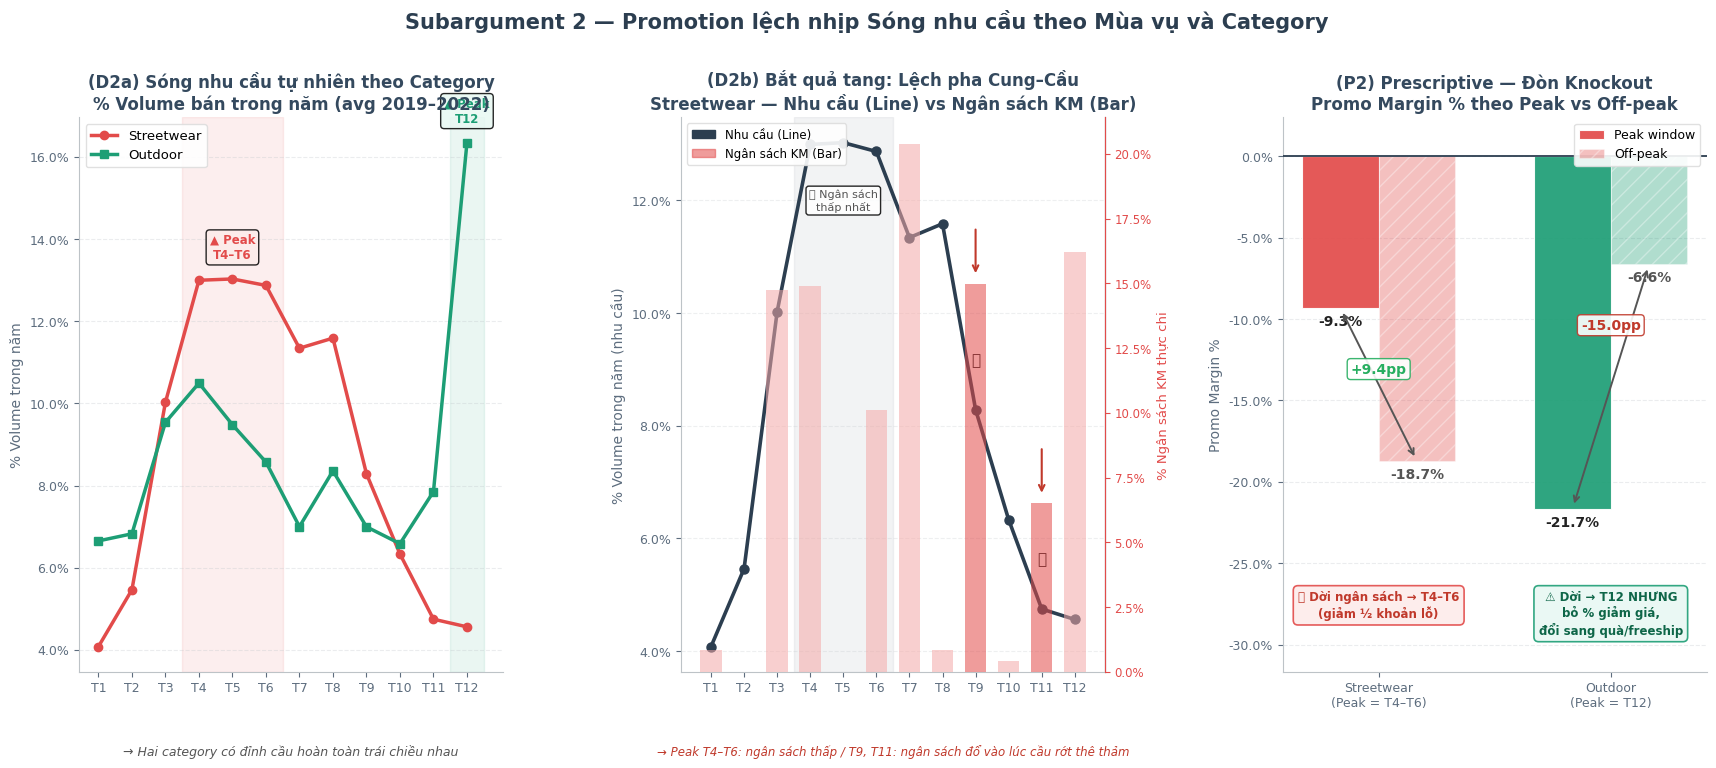

✅ Saved: fig2_subarg2_final.png


In [18]:
# ════════════════════════════════════════════════════════════════════════════
# FIGURE 2  —  SUBARG 2  (Rewritten — final version)
# D2a : Multi-line — Volume share theo tháng (Streetwear vs Outdoor)
# D2b : Dual-axis Combo (Line + Bar) — Streetwear: nhu cầu vs ngân sách KM
# P2  : Grouped Bar — Promo Margin % Peak vs Off-peak (Streetwear & Outdoor)
# ════════════════════════════════════════════════════════════════════════════

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# ── Config ────────────────────────────────────────────────────────────────────
try:
    INPUT_DIR
except NameError:
    INPUT_DIR = Path('input')

OUTPUT_DIR = Path('output')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

C_COLORS  = {'Outdoor': '#1D9E75', 'Streetwear': '#E24B4A',
             'Casual': '#2E86AB', 'GenZ': '#EF9F27'}
MONTHS    = ['T1','T2','T3','T4','T5','T6','T7','T8','T9','T10','T11','T12']

FONT_SUP   = dict(fontsize=15, fontweight='bold', color='#2C3E50')
FONT_TITLE = dict(fontsize=12, fontweight='bold', color='#34495E')
FONT_LABEL = dict(fontsize=10, color='#5D6D7E')

def style_ax(ax, grid_axis='y', keep_right_spine=False):
    ax.spines['top'].set_visible(False)
    if not keep_right_spine:
        ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#BDC3C7')
    ax.spines['bottom'].set_color('#BDC3C7')
    ax.tick_params(colors='#5D6D7E', labelsize=9)
    ax.set_axisbelow(True)
    if grid_axis == 'y':
        ax.grid(axis='y', linestyle='--', alpha=0.3, color='#BDC3C7', zorder=0)
    elif grid_axis == 'x':
        ax.grid(axis='x', linestyle='--', alpha=0.3, color='#BDC3C7', zorder=0)

# ── Load & transform ──────────────────────────────────────────────────────────
orders      = pd.read_csv(INPUT_DIR / 'orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv(INPUT_DIR / 'order_items.csv')
products    = pd.read_csv(INPUT_DIR / 'products.csv')

orders['year']  = orders['order_date'].dt.year
orders['month'] = orders['order_date'].dt.month

df = (order_items
      .merge(orders[['order_id', 'year', 'month']], on='order_id', how='left')
      .merge(products[['product_id', 'category', 'cogs']], on='product_id', how='left'))

df['discount_amount'] = df['discount_amount'].fillna(0).abs()
df['gross_revenue']   = df['unit_price'] * df['quantity']
df['net_revenue']     = df['gross_revenue'] - df['discount_amount']
df['total_cogs']      = df['cogs'] * df['quantity']
df['gross_profit']    = df['net_revenue'] - df['total_cogs']

df_1922  = df[df['year'].between(2019, 2022)].copy()
promo_df = df_1922[df_1922['discount_amount'] > 0].copy()

# peak label
def assign_peak(row):
    if row['category'] == 'Streetwear' and row['month'] in [4, 5, 6]:
        return 'Peak'
    if row['category'] == 'Outdoor' and row['month'] == 12:
        return 'Peak'
    return 'Off-peak'

promo_df['peak_label'] = promo_df.apply(assign_peak, axis=1)

# ── D2a data: Volume share by month ───────────────────────────────────────────
sw_od = df[df['category'].isin(['Streetwear', 'Outdoor'])].copy()

vol_yr = (sw_od.groupby(['category', 'year', 'month'])['quantity']
          .sum().reset_index(name='qty'))
yr_total = (vol_yr.groupby(['category', 'year'])['qty']
            .sum().reset_index(name='yr_qty'))
vol_yr = vol_yr.merge(yr_total, on=['category', 'year'])
vol_yr['month_share'] = vol_yr['qty'] / vol_yr['yr_qty'] * 100

avg_vol = (vol_yr.groupby(['category', 'month'])['month_share']
           .mean().reset_index())

sw_vol = avg_vol[avg_vol['category'] == 'Streetwear'].set_index('month')['month_share'].reindex(range(1,13), fill_value=0)
od_vol = avg_vol[avg_vol['category'] == 'Outdoor'].set_index('month')['month_share'].reindex(range(1,13), fill_value=0)

# ── D2b data: Streetwear — Volume share vs Promo budget share by month ────────
sw_items = df_1922[df_1922['category'] == 'Streetwear'].copy()

# Volume share (natural demand) — reuse sw_vol
# Promo budget share by month for Streetwear
sw_promo = sw_items[sw_items['discount_amount'] > 0].copy()
promo_by_month = sw_promo.groupby('month')['discount_amount'].sum().reindex(range(1,13), fill_value=0)
promo_share = promo_by_month / promo_by_month.sum() * 100  # % of annual promo budget

# ── P2 data ───────────────────────────────────────────────────────────────────
p2_cats = promo_df[promo_df['category'].isin(['Streetwear', 'Outdoor'])].copy()

p2_agg = (p2_cats.groupby(['category', 'peak_label'])
          .agg(total_profit=('gross_profit', 'sum'),
               total_net_rev=('net_revenue', 'sum'))
          .reset_index())
p2_agg['promo_margin'] = p2_agg['total_profit'] / p2_agg['total_net_rev'] * 100

# ════════════════════════════════════════════════════════════════════════════
# DRAW
# ════════════════════════════════════════════════════════════════════════════
fig2 = plt.figure(figsize=(21, 7.2), facecolor='white')
fig2.suptitle(
    'Subargument 2 — Promotion lệch nhịp Sóng nhu cầu theo Mùa vụ và Category',
    **FONT_SUP, y=1.03
)
gs = gridspec.GridSpec(1, 3, figure=fig2, wspace=0.42)

x = np.arange(1, 13)

# ─────────────────────────────────────────────────────────────────────────────
# D2a — Multi-line: Volume share Streetwear vs Outdoor
# ─────────────────────────────────────────────────────────────────────────────
ax1 = fig2.add_subplot(gs[0])

# Shaded peak windows
ax1.axvspan(3.5, 6.5, color='#E24B4A', alpha=0.09, zorder=0)
ax1.axvspan(11.5, 12.5, color='#1D9E75', alpha=0.09, zorder=0)

ax1.plot(x, sw_vol.values, color='#E24B4A', linewidth=2.5,
         marker='o', markersize=6, zorder=4, label='Streetwear')
ax1.plot(x, od_vol.values, color='#1D9E75', linewidth=2.5,
         marker='s', markersize=6, zorder=4, label='Outdoor')

# Peak labels inside shaded area
sw_peak_y = sw_vol[[4, 5, 6]].max()
ax1.text(5, sw_peak_y + 0.5, '▲ Peak\nT4–T6',
         ha='center', fontsize=8.5, color='#E24B4A',
         fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3', fc='#fdecea', alpha=0.85))
ax1.text(12, od_vol[12] + 0.5, '▲ Peak\nT12',
         ha='center', fontsize=8.5, color='#1D9E75',
         fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3', fc='#e8f8f3', alpha=0.85))

ax1.set_title('(D2a) Sóng nhu cầu tự nhiên theo Category\n% Volume bán trong năm (avg 2019–2022)', **FONT_TITLE)
ax1.set_ylabel('% Volume trong năm', **FONT_LABEL)
ax1.set_xticks(x)
ax1.set_xticklabels(MONTHS, fontsize=9)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.1f}%'))
ax1.legend(fontsize=9.5, loc='upper left',
           framealpha=0.9, edgecolor='#ddd')
style_ax(ax1)

# insight note bottom
ax1.text(0.5, -0.15,
         '→ Hai category có đỉnh cầu hoàn toàn trái chiều nhau',
         transform=ax1.transAxes, ha='center', fontsize=9,
         color='#555', style='italic')

# ─────────────────────────────────────────────────────────────────────────────
# D2b — Dual-axis Combo: Streetwear demand (line) vs promo budget (bar)
# ─────────────────────────────────────────────────────────────────────────────
ax2 = fig2.add_subplot(gs[1])
ax2r = ax2.twinx()

# — Bars: Promo budget share (Y2, right axis) —
bar_colors_d2b = ['#E24B4A' if m in [9, 11] else '#f4a9a8' for m in range(1, 13)]
bars = ax2r.bar(x, promo_share.values, color=bar_colors_d2b,
                alpha=0.55, width=0.65, zorder=2, label='% Ngân sách KM')
ax2r.set_ylabel('% Ngân sách KM thực chi', fontsize=9.5, color='#E24B4A')
ax2r.tick_params(axis='y', colors='#E24B4A', labelsize=8.5)
ax2r.spines['top'].set_visible(False)
ax2r.spines['right'].set_color('#E24B4A')
ax2r.spines['left'].set_visible(False)
ax2r.spines['bottom'].set_visible(False)
ax2r.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.1f}%'))

# — Line: Natural demand (Y1, left axis) —
ax2.plot(x, sw_vol.values, color='#2C3E50', linewidth=2.6,
         marker='o', markersize=6.5, zorder=5, label='% Volume nhu cầu')
ax2.set_ylabel('% Volume trong năm (nhu cầu)', **FONT_LABEL)
ax2.set_xticks(x)
ax2.set_xticklabels(MONTHS, fontsize=9)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.1f}%'))

# Shade peak demand window (T4–T6) on D2b too
ax2.axvspan(3.5, 6.5, color='#2C3E50', alpha=0.06, zorder=0)

# Highlight "mismatch" months: demand low, budget high → T9, T11
for m, bad_m in enumerate([9, 11], start=1):
    b_y = promo_share[bad_m]
    d_y = sw_vol[bad_m]
    ax2r.annotate('',
        xy=(bad_m, b_y + 0.3),
        xytext=(bad_m, b_y + 2.2),
        arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.5))

# Text boxes for mismatch
ax2.text(9, sw_vol[9] + 0.8, '❌', ha='center', fontsize=11, zorder=6)
ax2.text(11, sw_vol[11] + 0.8, '❌', ha='center', fontsize=11, zorder=6)
ax2.text(5, sw_vol[[4,5,6]].max() - 1.2, '📉 Ngân sách\nthấp nhất',
         ha='center', fontsize=8, color='#555', zorder=6,
         bbox=dict(boxstyle='round,pad=0.25', fc='white', alpha=0.85))

# Legend
h_line = mpatches.Patch(color='#2C3E50', label='Nhu cầu (Line)')
h_bar  = mpatches.Patch(color='#E24B4A', alpha=0.55, label='Ngân sách KM (Bar)')
ax2.legend(handles=[h_line, h_bar], fontsize=8.5, loc='upper left',
           framealpha=0.9, edgecolor='#ddd')

ax2.set_title('(D2b) Bắt quả tang: Lệch pha Cung–Cầu\nStreetwear — Nhu cầu (Line) vs Ngân sách KM (Bar)', **FONT_TITLE)
style_ax(ax2, keep_right_spine=True)
ax2.grid(axis='y', linestyle='--', alpha=0.25, color='#BDC3C7', zorder=0)

ax2.text(0.5, -0.15,
         '→ Peak T4–T6: ngân sách thấp / T9, T11: ngân sách đổ vào lúc cầu rớt thê thảm',
         transform=ax2.transAxes, ha='center', fontsize=8.5,
         color='#c0392b', style='italic')

# ─────────────────────────────────────────────────────────────────────────────
# P2 — Grouped Bar: Promo Margin % Peak vs Off-peak
# ─────────────────────────────────────────────────────────────────────────────
ax3 = fig2.add_subplot(gs[2])

cats_p2 = ['Streetwear', 'Outdoor']
x_p2    = np.arange(len(cats_p2))
width   = 0.33

peak_margins, offpeak_margins = [], []
for cat in cats_p2:
    sub = p2_agg[p2_agg['category'] == cat]
    pk  = sub[sub['peak_label'] == 'Peak']['promo_margin'].values
    op  = sub[sub['peak_label'] == 'Off-peak']['promo_margin'].values
    peak_margins.append(pk[0] if len(pk) else 0)
    offpeak_margins.append(op[0] if len(op) else 0)

print("P2 margins →")
for cat, pk, op in zip(cats_p2, peak_margins, offpeak_margins):
    print(f"  {cat}: Peak={pk:.2f}%, Off-peak={op:.2f}%  Δ={pk-op:+.2f}pp")

# Draw bars
bars_pk = ax3.bar(x_p2 - width/2, peak_margins, width,
                  color=[C_COLORS[c] for c in cats_p2],
                  alpha=0.92, label='Peak window', zorder=3,
                  edgecolor='white', linewidth=0.8)
bars_op = ax3.bar(x_p2 + width/2, offpeak_margins, width,
                  color=[C_COLORS[c] for c in cats_p2],
                  alpha=0.35, label='Off-peak', zorder=3,
                  edgecolor='white', linewidth=0.8, hatch='//')

# Value labels on bars
for bar, val, solid in zip(list(bars_pk) + list(bars_op),
                            peak_margins + offpeak_margins,
                            [True]*2 + [False]*2):
    fc  = '#222' if solid else '#555'
    va  = 'top' if val < 0 else 'bottom'
    off = -0.4 if val < 0 else 0.4
    ax3.text(bar.get_x() + bar.get_width()/2, val + off,
             f'{val:.1f}%', ha='center', va=va,
             fontsize=10, fontweight='bold', color=fc)

# Break-even
ax3.axhline(y=0, color='#2C3E50', linewidth=1.3, zorder=5)

# Delta annotation (double-headed arrow between bar tops/bottoms)
for i, (pk, op, cat) in enumerate(zip(peak_margins, offpeak_margins, cats_p2)):
    delta = pk - op
    sign  = '+' if delta >= 0 else ''
    # Arrow between the *tips* of the two bars
    y_pk = pk
    y_op = op
    y_hi = max(y_pk, y_op)
    y_lo = min(y_pk, y_op)
    # Draw bracket arrow
    ax3.annotate('',
        xy  =(i - width/2, y_pk),
        xytext=(i + width/2, y_op),
        arrowprops=dict(arrowstyle='<->', color='#555',
                        lw=1.4, shrinkA=4, shrinkB=4))
    # Delta label: place above the higher of the two
    label_y = y_hi + (2.5 if y_hi >= 0 else -4)
    ax3.text(i, label_y,
             f'{sign}{delta:.1f}pp',
             ha='center', fontsize=10, fontweight='bold',
             color='#27ae60' if delta > 0 else '#c0392b',
             bbox=dict(boxstyle='round,pad=0.25', fc='white',
                       ec='#27ae60' if delta > 0 else '#c0392b',
                       alpha=0.9))

# ── Insight annotation boxes ──────────────────────────────────────────────────
y_min = min(peak_margins + offpeak_margins)
box_y = y_min - 5  # position below lowest bar

# Streetwear insight
ax3.text(0, box_y,
         '✅ Dời ngân sách → T4–T6\n(giảm ½ khoản lỗ)',
         ha='center', va='top', fontsize=8.5,
         color='#c0392b', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.4', fc='#fdecea',
                   ec='#E24B4A', alpha=0.9, linewidth=1.2))

# Outdoor insight
ax3.text(1, box_y,
         '⚠️ Dời → T12 NHƯNG\nbỏ % giảm giá,\nđổi sang quà/freeship',
         ha='center', va='top', fontsize=8.5,
         color='#0e6648', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.4', fc='#e8f8f3',
                   ec='#1D9E75', alpha=0.9, linewidth=1.2))

# Adjust y-limit to show insight boxes
ax3.set_ylim(box_y - 5, max(peak_margins + offpeak_margins) + 9)

ax3.set_title('(P2) Prescriptive — Đòn Knockout\nPromo Margin % theo Peak vs Off-peak', **FONT_TITLE)
ax3.set_ylabel('Promo Margin %', **FONT_LABEL)
ax3.set_xticks(x_p2)
ax3.set_xticklabels(['Streetwear\n(Peak = T4–T6)', 'Outdoor\n(Peak = T12)'], fontsize=10)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.1f}%'))
ax3.legend(fontsize=9, loc='upper right', framealpha=0.9, edgecolor='#ddd')
style_ax(ax3)

plt.tight_layout(rect=[0, 0.02, 1, 1])
fig2.savefig(OUTPUT_DIR / 'fig2_subarg2_final.png', dpi=200,
             bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Saved: fig2_subarg2_final.png')

inventory columns: ['snapshot_date', 'product_id', 'stock_on_hand', 'units_received', 'units_sold', 'stockout_days', 'days_of_supply', 'fill_rate', 'stockout_flag', 'overstock_flag', 'reorder_flag', 'sell_through_rate', 'product_name', 'category', 'segment', 'year', 'month']
✅ Dùng year column: 'year'
✅ Base year (index = 100): 2012

── Outdoor Index ──
 year  stock_on_hand  units_sold  stock_idx  sales_idx
 2012          63857       86661 100.000000 100.000000
 2013         224986      182048 352.327858 210.069120
 2014         342245      184038 535.955338 212.365424
 2015         412047      169040 645.265202 195.058908
 2016         471063      148879 737.684201 171.794694
 2017         519130      126548 812.957076 146.026471
 2018         548257       88050 858.569930 101.602797
 2019         545725       60600 854.604820  69.927649
 2020         554297       45735 868.028564  52.774604
 2021         528203       39006 827.165385  45.009866
 2022         540081       39395 845.76

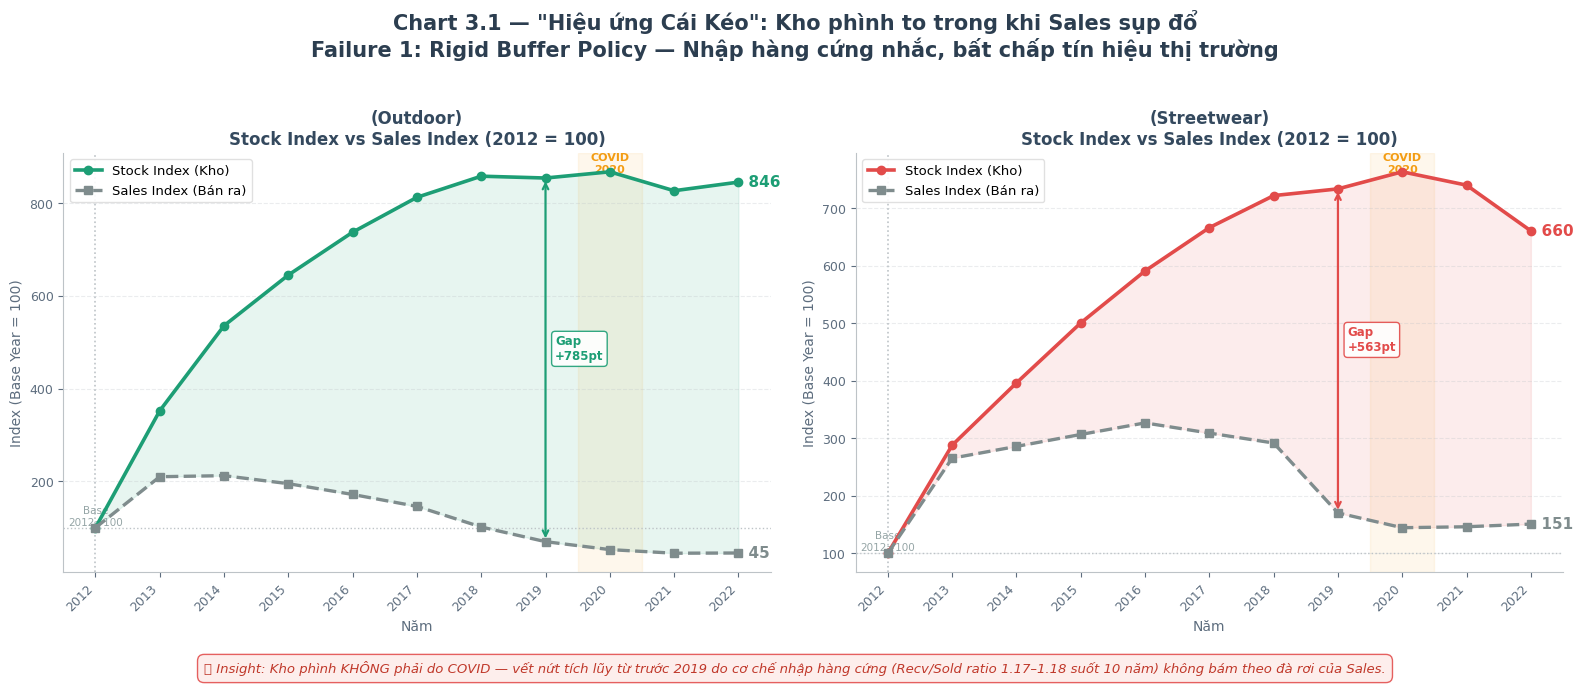

✅ Saved: fig3_1_scissors_effect.png


In [19]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 1 — Chart 3.1: "Hiệu ứng Cái Kéo" — Scissors Effect
# Dual-panel Index chart: Outdoor (left) + Streetwear (right)
# ═══════════════════════════════════════════════════════════════════════════

# ── DATA PREP ────────────────────────────────────────────────────────────────

# Lấy year từ orders
orders['year'] = orders['order_date'].dt.year

# Join order_items → orders → products để lấy category + qty sold per year
sales = (order_items
         .merge(orders[['order_id', 'year']], on='order_id', how='left')
         .merge(products[['product_id', 'category']], on='product_id', how='left'))

sales_yr = (sales.groupby(['category', 'year'])['quantity']
            .sum().reset_index(name='units_sold'))

# Inventory: stock_on_hand per category per year
# (nếu inventory có cột 'year' thì dùng thẳng; nếu không thì group theo year nếu có)
inv_cols = inventory.columns.tolist()
print("inventory columns:", inv_cols)

# Detect year column dynamically
year_col = None
for c in ['year', 'Year', 'fiscal_year', 'snapshot_year']:
    if c in inv_cols:
        year_col = c
        break

if year_col is None:
    # Thử parse từ date column nếu có
    date_cols = [c for c in inv_cols if 'date' in c.lower()]
    if date_cols:
        inventory['_year'] = pd.to_datetime(inventory[date_cols[0]], errors='coerce').dt.year
        year_col = '_year'
    else:
        raise ValueError(f"Không tìm thấy cột year trong inventory. Columns: {inv_cols}")

print(f"✅ Dùng year column: '{year_col}'")

inv_yr = (inventory.groupby(['category', year_col])['stock_on_hand']
          .sum().reset_index()
          .rename(columns={year_col: 'year'}))

# Merge sales + stock
merged = inv_yr.merge(sales_yr, on=['category', 'year'], how='outer').fillna(0)
merged = merged.sort_values(['category', 'year'])

# BASE YEAR = năm nhỏ nhất có đủ cả 2 metrics
base_year = int(merged[merged['units_sold'] > 0]['year'].min())
print(f"✅ Base year (index = 100): {base_year}")

# Tính index cho từng category
def make_index(df, cat):
    d = df[df['category'] == cat].copy().sort_values('year')
    base_stock = d.loc[d['year'] == base_year, 'stock_on_hand'].values
    base_sales = d.loc[d['year'] == base_year, 'units_sold'].values
    if len(base_stock) == 0 or base_stock[0] == 0:
        base_stock = np.array([d['stock_on_hand'].iloc[0]])
    if len(base_sales) == 0 or base_sales[0] == 0:
        base_sales = np.array([d['units_sold'].iloc[0]])
    d['stock_idx'] = d['stock_on_hand'] / base_stock[0] * 100
    d['sales_idx'] = d['units_sold']    / base_sales[0] * 100
    return d

od_idx = make_index(merged, 'Outdoor')
sw_idx = make_index(merged, 'Streetwear')

print("\n── Outdoor Index ──")
print(od_idx[['year','stock_on_hand','units_sold','stock_idx','sales_idx']].to_string(index=False))
print("\n── Streetwear Index ──")
print(sw_idx[['year','stock_on_hand','units_sold','stock_idx','sales_idx']].to_string(index=False))

# ── DRAW ─────────────────────────────────────────────────────────────────────
fig31, (ax_od, ax_sw) = plt.subplots(1, 2, figsize=(16, 6.2), facecolor='white')
fig31.suptitle(
    'Chart 3.1 — "Hiệu ứng Cái Kéo": Kho phình to trong khi Sales sụp đổ\n'
    'Failure 1: Rigid Buffer Policy — Nhập hàng cứng nhắc, bất chấp tín hiệu thị trường',
    **FONT_SUP, y=1.03
)

def draw_scissors(ax, df, cat, color):
    years = df['year'].values
    s_idx = df['stock_idx'].values
    d_idx = df['sales_idx'].values

    # Shade area between 2 lines (diverge zone)
    ax.fill_between(years, s_idx, d_idx,
                    where=(s_idx >= d_idx),
                    alpha=0.10, color=color, zorder=0, label='_nolegend_')
    ax.fill_between(years, s_idx, d_idx,
                    where=(s_idx < d_idx),
                    alpha=0.07, color='#27ae60', zorder=0, label='_nolegend_')

    # COVID reference band
    ax.axvspan(2019.5, 2020.5, color='#f39c12', alpha=0.08, zorder=0)
    ax.text(2020, ax.get_ylim()[1] if ax.get_ylim()[1] > 10 else 220,
            'COVID\n2020', ha='center', fontsize=8, color='#f39c12',
            fontweight='bold', va='top')

    # Lines
    ax.plot(years, s_idx, color=color, linewidth=2.6,
            marker='o', markersize=6, zorder=4, label='Stock Index (Kho)')
    ax.plot(years, d_idx, color='#7f8c8d', linewidth=2.4,
            marker='s', markersize=5.5, zorder=4,
            linestyle='--', label='Sales Index (Bán ra)')

    # Base year marker
    ax.axvline(x=base_year, color='#bdc3c7', linewidth=1.2,
               linestyle=':', zorder=1)
    ax.text(base_year, 105, f'Base\n{base_year}=100',
            ha='center', fontsize=7.5, color='#95a5a6')

    # End-point labels (endpoint annotation)
    last_yr = years[-1]
    ax.annotate(f"  {s_idx[-1]:.0f}",
                xy=(last_yr, s_idx[-1]),
                fontsize=11, fontweight='bold', color=color,
                va='center')
    ax.annotate(f"  {d_idx[-1]:.0f}",
                xy=(last_yr, d_idx[-1]),
                fontsize=11, fontweight='bold', color='#7f8c8d',
                va='center')

    # Diverge annotation arrow
    mid_year = int(np.median(years[years >= 2016]))
    s_mid = np.interp(mid_year, years, s_idx)
    d_mid = np.interp(mid_year, years, d_idx)
    if s_mid > d_mid + 10:
        ax.annotate('',
            xy=(mid_year, s_mid + 2),
            xytext=(mid_year, d_mid - 2),
            arrowprops=dict(arrowstyle='<->', color=color,
                            lw=1.6, shrinkA=3, shrinkB=3))
        gap = s_mid - d_mid
        ax.text(mid_year + 0.15, (s_mid + d_mid) / 2,
                f'Gap\n+{gap:.0f}pt',
                fontsize=8.5, color=color, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', fc='white',
                          ec=color, alpha=0.9))

    # Styling
    ax.set_title(f'({cat})\nStock Index vs Sales Index ({base_year} = 100)',
                 **FONT_TITLE)
    ax.set_ylabel('Index (Base Year = 100)', **FONT_LABEL)
    ax.set_xlabel('Năm', **FONT_LABEL)
    ax.axhline(y=100, color='#bdc3c7', linewidth=1.0, linestyle=':', zorder=1)
    ax.legend(fontsize=9.5, loc='upper left', framealpha=0.9, edgecolor='#ddd')
    style_ax(ax)
    ax.set_xticks(years[::1])
    ax.set_xticklabels([str(int(y)) for y in years], rotation=45, ha='right')

# Draw both panels — set y-lim after so COVID label can reference it
draw_scissors(ax_od, od_idx, 'Outdoor',    C_COLORS['Outdoor'])
draw_scissors(ax_sw, sw_idx, 'Streetwear', C_COLORS['Streetwear'])

# Insight note at bottom
fig31.text(0.5, -0.04,
    '💡 Insight: Kho phình KHÔNG phải do COVID — vết nứt tích lũy từ trước 2019 do cơ chế '
    'nhập hàng cứng (Recv/Sold ratio 1.17–1.18 suốt 10 năm) không bám theo đà rơi của Sales.',
    ha='center', fontsize=9.5, color='#c0392b', style='italic',
    bbox=dict(boxstyle='round,pad=0.5', fc='#fdecea', ec='#E24B4A', alpha=0.88))

plt.tight_layout()
fig31.savefig(OUTPUT_DIR / 'fig3_1_scissors_effect.png', dpi=200,
              bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Saved: fig3_1_scissors_effect.png')